## Task 4 Neural Networks

Two multi-layer-perceptron classifiers for `is_accepted`, both tuned with `GridSearchCV`:

4.2 neural network on all features
4.3 neural network on the reduced feature set chosen by the best Task 2 decision tree
4.1 / 4.4 extra preprocessing, and ROC curves for both models

In [1]:
import warnings
warnings.filterwarnings('ignore')   

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('dataset_ifn580_262_v1.csv')

df = df.drop(columns=['car'])                                  
df['temperature'] = df['temperature'].fillna(df['temperature'].median())
for col in ['Bar', 'CoffeeHouse', 'CarryAway',
            'RestaurantLessThan20', 'Restaurant20To50']:
    df[col] = df[col].fillna(df[col].mode()[0])

df['age'] = df['age'].map({'below21':0,'21':1,'26':2,'31':3,'36':4,'41':5,'46':6,'50plus':7})
df['time'] = df['time'].map({'7AM':0,'10AM':1,'2PM':2,'6PM':3,'10PM':4})
df['income'] = df['income'].map({'Less than $12500':0,'$12500 - $24999':1,'$25000 - $37499':2,
                                 '$37500 - $49999':3,'$50000 - $62499':4,'$62500 - $74999':5,
                                 '$75000 - $87499':6,'$87500 - $99999':7,'$100000 or More':8})
df['education'] = df['education'].map({'Some High School':0,'High School Graduate':1,
                                      'Some college - no degree':2,'Associates degree':3,
                                      'Bachelors degree':4,
                                      'Graduate degree (Masters or Doctorate)':5})
freq_map = {'never':0,'less1':1,'1~3':2,'4~8':3,'gt8':4}
for col in ['Bar','CoffeeHouse','CarryAway','RestaurantLessThan20','Restaurant20To50']:
    df[col] = df[col].map(freq_map)
df['expiration'] = df['expiration'].map({'2h':0,'1d':1})
df['gender'] = df['gender'].map({'Female':0,'Male':1})

df = pd.concat([df, pd.get_dummies(df['destination'], prefix='destination', dtype=int)], axis=1)
df = df.drop(columns=['destination'])
nominal_columns = ['passanger','weather','coupon','maritalStatus','occupation']
df = pd.concat([df, pd.get_dummies(df[nominal_columns], prefix=nominal_columns, dtype=int)], axis=1)
df = df.drop(columns=nominal_columns)

df = df.drop(columns=['direction_opp'])           

print("processed shape:", df.shape, "| missing:", int(df.isnull().sum().sum()))

processed shape: (12684, 63) | missing: 0


In [2]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['is_accepted'])
y = df['is_accepted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

feature_names = X.columns
print("train:", X_train.shape, " test:", X_test.shape)

train: (8878, 62)  test: (3806, 62)


## 4.1 Additional processing required for the neural network

On top of the shared Task 1 preprocessing (numeric encoding, missing-value imputation,
one-hot encoding, correlation-based removal), a neural network needs:

Feature standardisation: every input is rescaled to mean 0 / standard deviation 1
  with `StandardScaler`, fitted on the training set only and then applied to both sets.
  The MLP is trained by gradient descent, which is scale-sensitive: without this, wide-range
  inputs such as `income` (0–8) or `time` (0–4) would dominate the weight updates and the
  network would train poorly. (This is the same requirement as the logistic-regression model
  in Task 3.)
A raised iteration cap: `max_iter` is set to 1000 so the Adam optimiser has enough
  iterations to converge (the sklearn default of 200 is far too low and stops with a convergence warning).

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train, y_train)
X_test_scaled = scaler.transform(X_test)

print("before scaling  -> first row min/max:",
      round(X_train.values[0].min(), 2), round(X_train.values[0].max(), 2))
print("after  scaling  -> column means ~0:",
      np.round(X_train_scaled.mean(axis=0)[:5], 3),
      " column stds ~1:", np.round(X_train_scaled.std(axis=0)[:5], 3))

before scaling  -> first row min/max: 0.0 55.0
after  scaling  -> column means ~0: [ 0. -0. -0. -0. -0.]  column stds ~1: [1. 1. 1. 1. 1.]


## 4.2 Neural network tuned with GridSearchCV

Fixed parameters (and why):

| Parameter | Value | Reason |
|---|---|---|
| `activation` | `relu` | default in sklearn; trains fast and avoids vanishing gradients |
| `solver` | `adam` | adaptive gradient descent, the standard choice for this size of data |
| `max_iter` | `1000` | high enough for Adam to fully converge on this dataset |
| `random_state` | `42` | reproducibility, consistent with Tasks 2 and 3 |

Searched hyperparameters:

 `hidden_layer_sizes` ∈ {(5,), (10,), (20,), (40,), (n_features,)} – one hidden layer,
  from very small up to one neuron per input. Week 6 guidance is to keep the hidden layer
  between the output size (1) and the input size, and the simpler models in Tasks 2–3
  generalised better on this data, so small sizes are included.
 `alpha` ∈ {1e-4, 1e-3, 1e-2, 1e-1} – L2 regularisation strength (default 1e-4), spanning
  two orders of magnitude to control over-fitting.

`cv=5` (5-fold cross-validation), matching the Task 2 grid search.

In [4]:
import time
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

n_features = X_train_scaled.shape[1]

mlp_param_grid = {
    'hidden_layer_sizes': [(5,), (10,), (20,), (40,), (n_features,)],
    'alpha': [1e-4, 1e-3, 1e-2, 1e-1],
}

mlp_base = MLPClassifier(activation='relu', solver='adam',
                         max_iter=1000, random_state=42)

start = time.time()
mlp_grid = GridSearchCV(mlp_base, param_grid=mlp_param_grid,
                        cv=5, scoring='accuracy', n_jobs=-1)
mlp_grid.fit(X_train_scaled, y_train)
mlp_grid_time = time.time() - start

mlp_best = mlp_grid.best_estimator_
print("Best parameters:", mlp_grid.best_params_)
print("Best CV score  :", round(mlp_grid.best_score_, 4))
print(f"GridSearchCV time: {mlp_grid_time:.1f} s")

Best parameters: {'alpha': 0.01, 'hidden_layer_sizes': (20,)}
Best CV score  : 0.7057
GridSearchCV time: 61.8 s


### 4.2b Classification accuracy

In [5]:
mlp_train_acc = mlp_best.score(X_train_scaled, y_train)
mlp_test_acc = mlp_best.score(X_test_scaled, y_test)
print("Training accuracy:", round(mlp_train_acc, 4))
print("Testing  accuracy:", round(mlp_test_acc, 4))
print()
print(classification_report(y_test, mlp_best.predict(X_test_scaled)))

Training accuracy: 0.8078
Testing  accuracy: 0.7099

              precision    recall  f1-score   support

           0       0.68      0.62      0.65      1649
           1       0.73      0.78      0.75      2157

    accuracy                           0.71      3806
   macro avg       0.70      0.70      0.70      3806
weighted avg       0.71      0.71      0.71      3806



### 4.2c Did the training process converge?

Iterations run (n_iter_): 450 of max_iter = 1000
Final training loss     : 0.4262
Converged (stopped on loss plateau, not the iteration cap): True


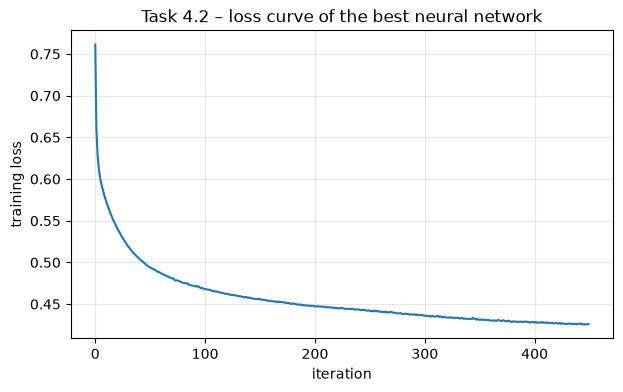

In [6]:
print("Iterations run (n_iter_):", mlp_best.n_iter_, "of max_iter =", 1000)
print("Final training loss     :", round(mlp_best.loss_, 4))
converged = mlp_best.n_iter_ < 1000
print("Converged (stopped on loss plateau, not the iteration cap):", converged)

plt.figure(figsize=(7, 4))
plt.plot(mlp_best.loss_curve_)
plt.xlabel("iteration"); plt.ylabel("training loss")
plt.title("Task 4.2 – loss curve of the best neural network")
plt.grid(alpha=0.3); plt.show()

The optimiser stopped **before** `max_iter`, so training converged (it halted because the
loss stopped improving, not because it ran out of iterations). `GridSearchCV` then selected
this configuration as the best of the searched grid by 5-fold cross-validation, so it is the
best model within the search space.

### 4.2d Sign of over-fitting?

In [7]:
print("Train accuracy :", round(mlp_train_acc, 4))
print("Test  accuracy :", round(mlp_test_acc, 4))
print("Train - test gap:", round(mlp_train_acc - mlp_test_acc, 4))

Train accuracy : 0.8078
Test  accuracy : 0.7099
Train - test gap: 0.0979


The training accuracy is higher than the test accuracy, so the network **does show some
over-fitting**. The gap is still much smaller than the default decision tree in Task 2
(≈ 0.33), and the L2 penalty (`alpha`) chosen by the grid search limits how far the network
memorises the training data. The reduced-feature model in 4.3 shrinks this gap further.

## 4.3 Neural network on the decision-tree-reduced feature set

The reduced feature set is chosen by the best Task 2 decision tree
(`criterion='entropy'`, `max_depth=10`, `min_samples_leaf=1`, `min_samples_split=20`).
`SelectFromModel` keeps the features whose tree importance is above the mean; the neural
network is then re-tuned with `GridSearchCV` on that smaller input.

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectFromModel

dt_tuned = DecisionTreeClassifier(criterion='entropy', max_depth=10,
                                  min_samples_leaf=1, min_samples_split=20,
                                  random_state=42)
dt_tuned.fit(X_train, y_train)

selector = SelectFromModel(dt_tuned, prefit=True, threshold='mean')
X_train_sel = selector.transform(X_train_scaled)
X_test_sel = selector.transform(X_test_scaled)

selected_features = list(feature_names[selector.get_support()])
print(f"features reduced: {X_train_scaled.shape[1]} -> {X_train_sel.shape[1]}")
print("network input variables:")
for f in selected_features:
    print("   ", f)

features reduced: 62 -> 16
network input variables:
    temperature
    time
    expiration
    age
    education
    income
    Bar
    CoffeeHouse
    CarryAway
    RestaurantLessThan20
    Restaurant20To50
    toCoupon_GEQ25min
    passanger_Friend(s)
    coupon_Carry out & Take away
    coupon_Coffee House
    coupon_Restaurant(<20)


### 4.3a Did feature selection favour the outcome, and how did the architecture change?

In [9]:
n_sel = X_train_sel.shape[1]
mlp_param_grid_sel = {
    'hidden_layer_sizes': [(3,), (5,), (7,), (n_sel,)],
    'alpha': [1e-4, 1e-3, 1e-2],
}

start = time.time()
mlp_grid_sel = GridSearchCV(
    MLPClassifier(activation='relu', solver='adam', max_iter=1000, random_state=42),
    param_grid=mlp_param_grid_sel, cv=5, scoring='accuracy', n_jobs=-1)
mlp_grid_sel.fit(X_train_sel, y_train)
mlp_sel_time = time.time() - start
mlp_sel = mlp_grid_sel.best_estimator_

print("Full-feature best architecture   :", mlp_grid.best_params_['hidden_layer_sizes'],
      " alpha =", mlp_grid.best_params_['alpha'])
print("Reduced-feature best architecture :", mlp_grid_sel.best_params_['hidden_layer_sizes'],
      " alpha =", mlp_grid_sel.best_params_['alpha'])
print(f"GridSearchCV time: {mlp_sel_time:.1f} s  (vs {mlp_grid_time:.1f} s on all features)")

Full-feature best architecture   : (20,)  alpha = 0.01
Reduced-feature best architecture : (7,)  alpha = 0.001
GridSearchCV time: 9.2 s  (vs 61.8 s on all features)


### 4.3b Classification accuracy

In [10]:
mlp_sel_train_acc = mlp_sel.score(X_train_sel, y_train)
mlp_sel_test_acc = mlp_sel.score(X_test_sel, y_test)
print("Reduced NN training accuracy:", round(mlp_sel_train_acc, 4))
print("Reduced NN testing  accuracy:", round(mlp_sel_test_acc, 4))
print()
print(classification_report(y_test, mlp_sel.predict(X_test_sel)))

Reduced NN training accuracy: 0.7049
Reduced NN testing  accuracy: 0.6989

              precision    recall  f1-score   support

           0       0.67      0.59      0.63      1649
           1       0.72      0.78      0.75      2157

    accuracy                           0.70      3806
   macro avg       0.69      0.69      0.69      3806
weighted avg       0.70      0.70      0.70      3806



### 4.3c Iterations that kept improving before the final non-improving period

Total iterations run (n_iter_)      : 154
n_iter_no_change (patience)         : 10
Iteration with the lowest loss      : 154
=> training loss reached its minimum at iteration 154; the optimiser then
   needs 10 consecutive non-improving iterations to trigger the stop,
   so the improving phase is roughly the first 154 iterations (n_iter_ - patience = 144).


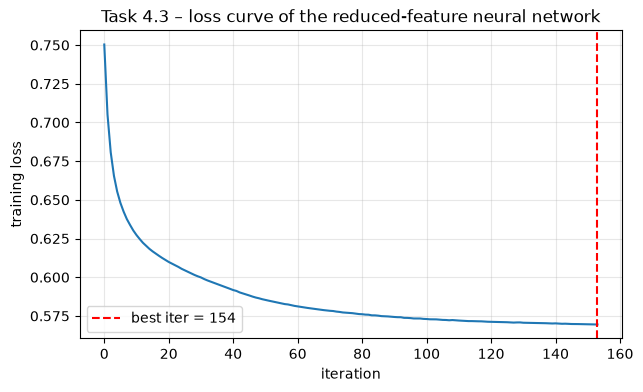

In [11]:
loss_curve = mlp_sel.loss_curve_
best_iter = int(np.argmin(loss_curve)) + 1
print("Total iterations run (n_iter_)      :", mlp_sel.n_iter_)
print("n_iter_no_change (patience)         :", mlp_sel.n_iter_no_change)
print("Iteration with the lowest loss      :", best_iter)
print(f"=> training loss reached its minimum at iteration {best_iter}; the optimiser then")
print(f"   needs {mlp_sel.n_iter_no_change} consecutive non-improving iterations to trigger the stop,")
print(f"   so the improving phase is roughly the first {best_iter} iterations "
      f"(n_iter_ - patience = {mlp_sel.n_iter_ - mlp_sel.n_iter_no_change}).")

plt.figure(figsize=(7, 4))
plt.plot(loss_curve)
plt.axvline(best_iter - 1, color='red', linestyle='--', label=f'best iter = {best_iter}')
plt.xlabel("iteration"); plt.ylabel("training loss")
plt.title("Task 4.3 – loss curve of the reduced-feature neural network")
plt.legend(); plt.grid(alpha=0.3); plt.show()

### 4.3d Over-fitting and convergence

In [12]:
print("Reduced NN train accuracy :", round(mlp_sel_train_acc, 4))
print("Reduced NN test  accuracy :", round(mlp_sel_test_acc, 4))
print("Train - test gap          :", round(mlp_sel_train_acc - mlp_sel_test_acc, 4))
print("Converged (n_iter_ < 1000) :", mlp_sel.n_iter_ < 1000, f"(n_iter_ = {mlp_sel.n_iter_})")

Reduced NN train accuracy : 0.7049
Reduced NN test  accuracy : 0.6989
Train - test gap          : 0.006
Converged (n_iter_ < 1000) : True (n_iter_ = 154)


## 4.4 ROC curves for both neural-network models

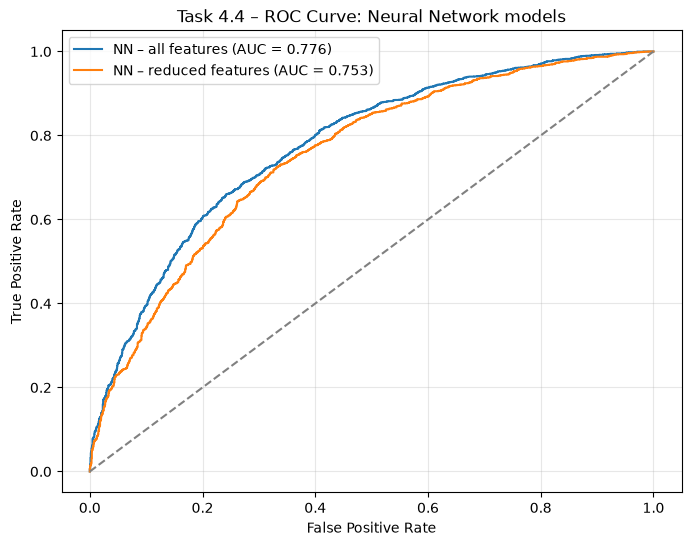

AUC – all features    : 0.7757
AUC – reduced features: 0.7528


In [13]:
from sklearn.metrics import roc_curve, roc_auc_score

proba_full = mlp_best.predict_proba(X_test_scaled)[:, 1]
proba_sel = mlp_sel.predict_proba(X_test_sel)[:, 1]

auc_full = roc_auc_score(y_test, proba_full)
auc_sel = roc_auc_score(y_test, proba_sel)
fpr_full, tpr_full, _ = roc_curve(y_test, proba_full)
fpr_sel, tpr_sel, _ = roc_curve(y_test, proba_sel)

plt.figure(figsize=(8, 6))
plt.plot(fpr_full, tpr_full, label=f"NN – all features (AUC = {auc_full:.3f})")
plt.plot(fpr_sel, tpr_sel, label=f"NN – reduced features (AUC = {auc_sel:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Task 4.4 – ROC Curve: Neural Network models")
plt.legend(); plt.grid(alpha=0.3); plt.show()

print("AUC – all features    :", round(auc_full, 4))
print("AUC – reduced features:", round(auc_sel, 4))

## Summary (Task 4)



In [14]:
import pandas as pd
summary = pd.DataFrame({
    "Model": ["NN – all features (4.2)", "NN – reduced features (4.3)"],
    "Train accuracy": [round(mlp_train_acc, 4), round(mlp_sel_train_acc, 4)],
    "Test accuracy": [round(mlp_test_acc, 4), round(mlp_sel_test_acc, 4)],
    "Train-test gap": [round(mlp_train_acc - mlp_test_acc, 4),
                       round(mlp_sel_train_acc - mlp_sel_test_acc, 4)],
    "Test AUC": [round(auc_full, 4), round(auc_sel, 4)],
    "n_iter_": [mlp_best.n_iter_, mlp_sel.n_iter_],
    "hidden_layer_sizes": [mlp_grid.best_params_['hidden_layer_sizes'],
                           mlp_grid_sel.best_params_['hidden_layer_sizes']],
})
summary

,Model,Train accuracy,Test accuracy,Train-test gap,Test AUC,n_iter_,hidden_layer_sizes
0,NN – all features (4.2),0.8078,0.7099,0.0979,0.7757,450,"(20,)"
1,NN – reduced features (4.3),0.7049,0.6989,0.0060,0.7528,154,"(7,)"
